### Problema 1

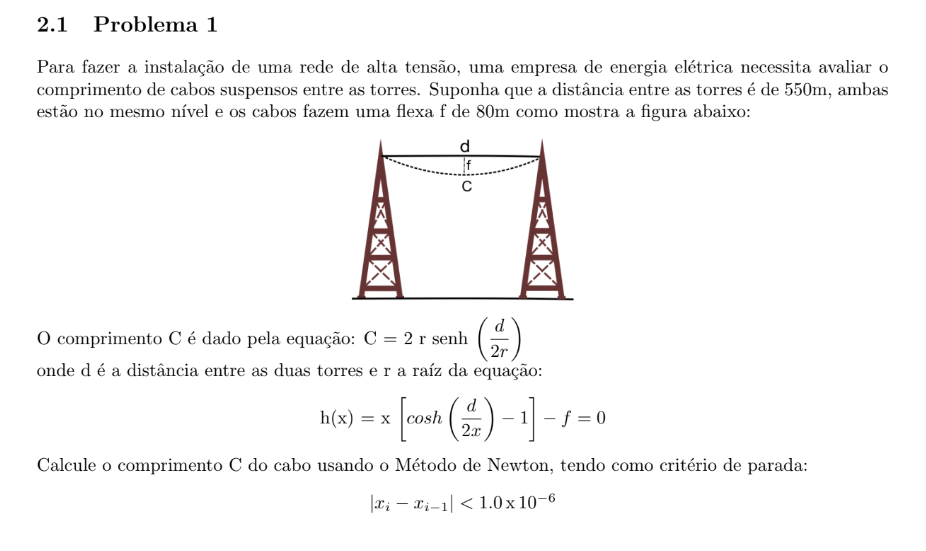

In [ ]:
# Utilizamos a biblioteca sympy para que o python reconheça as funções hiberbolicas senh(x) e cosh(x)
import sympy as sy
from sympy import cosh
from sympy import sinh

# Essas bibliotecas servem para plotar o gráfico da função para visualizarmos melhor onde se encontra a raiz
import matplotlib.pyplot as plt
import numpy as np

# Essa biblioteca vai gerar um número aleatório
import random

In [ ]:

# Temos que declarar a variável simbólica para podermos manipular dentro das funções trigonométricas que importaremos com o sympy
x = sy.Symbol('x')

# Criando a nossa função h(x)
def h(x):
  return x*(sy.cosh(550/(2*x))-1)-80

print(f'h(x)= {h(x)}')

# Criando a primeira derivada de h(x)
def h_1d(x):
  return sy.cosh(275/x) - 1 - 275*sy.sinh(275/x)/x

print(f'h´(x)=  {h_1d(x)}')

# Criando a segunda derivada de h(x)
def h_2d(x):
  return 75625*sy.cosh(275/x)/x**3

print(f'h´´(x) =  {h_2d(x)}')

# Criando a função do comprimento da corda C:

def comprimento(r):
  return 2*r*(sy.sinh(550 / (2*r)))

h(x)= x*(cosh(275/x) - 1) - 80
h´(x)=  cosh(275/x) - 1 - 275*sinh(275/x)/x
h´´(x) =  75625*cosh(275/x)/x**3


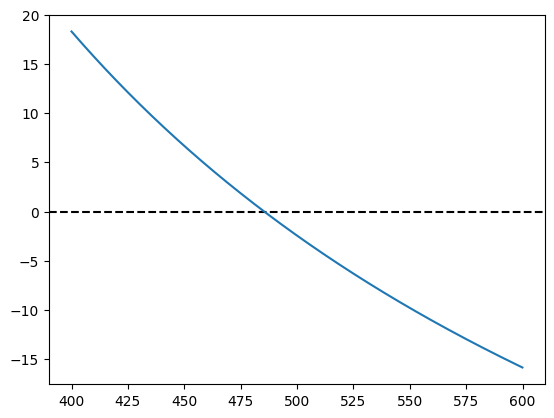

In [ ]:
# Aqui, nós iremos plotar o gráfico da função para termos uma noção de onde se encontram as raizes de h(x)
# A única raiz da função encontrada está no intervalo (400,500), que será o intervalo que vamos utilizar para extrair um valor inicial para o Método de Newton-Raphson

x = np.arange(400, 600, 0.1)   # start,stop,step

y= x*(np.cosh(550/(2*x))-1)-80


plt.axhline(y=0, color='black',linestyle='dashed')

plt.plot(x,y)

plt.show()

# Lembrando que h(x), h'(x) e h''(x) são contínuas em (400,500)

In [ ]:
# Agora partiremos para a execução do Método de Newton-Raphson, onde o objetivo é chegarmos num valor mais próximo possível da raiz de h(x), pois esse valor
# será o nosso valor r na função do comprimento da corda, e assim, podemos descobrir qual o tamanho da corda que liga as torres

# variável para o Critério de parada
e = 0.000001

# Aqui, vamos pegar um número aleatório dentro do intervalo (400,500). Esse x_n aqui seria equivalente ao valor inicial x0.
x_n = random.randint(400,501)

# O x_n1 corresponde ao nosso x^(n+1), ou seja, o x na (n+1) iteração. Essa expressão é o que iremos usar para iterar pelo método iterativo de Newton-Raphson
x_n1 = x_n - (h(x_n) / h_1d(x_n))

# A partir daqui, criaremos o nosso looping. Criamos a variável aux, que será explicada mais adiante e as variáveis i e N para fazermos um limite caso ocorra algum problema
# e assim impeça o computador de entrar em looping infinito.
aux = 0
i = 0
N = 1000

# O looping acontece caso o critério de parada do método ainda não tenha sido atendido e o o número de iterações está dentro do limite estipulado, caso qualquer uma dessas
# condições se tornem False, nosso looping acaba

while (abs(x_n-aux) >= e) and (i < N):
  #A variável aux, é uma variável auxiliar que recebe o nosso valor de x_n que acabou de ser iterado, assim, conferimos o criterio de parada e caso não seja atendido,
  # podemos continuar iterando novamente com o novo valor de x_n
  aux = x_n
  x_n1 = x_n - (h(x_n) / h_1d(x_n)) # valor x_n sendo iterado pelo Método N-R
  x_n = x_n1 # atualizamos o valor de x_n para o novo valor que achando iterando

  i += 1

print("Número de iterações:", i)
print("Valor de r:", round(x_n1, 7))
print("Valor de C:", round(comprimento(x_n1),7))



Número de iterações: 5
Valor de r: 485.4329502
Valor de C: 579.8940318


### Problema 2

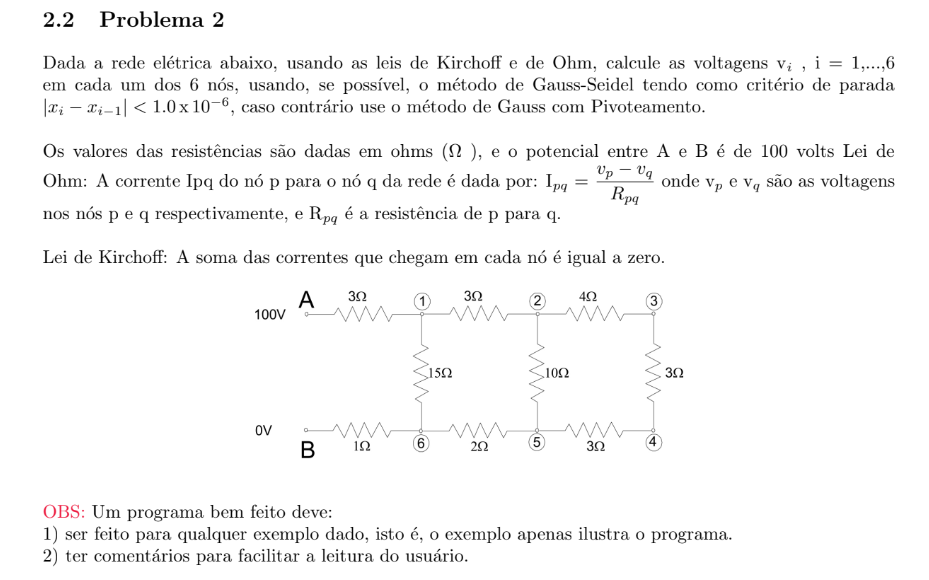

In [ ]:
# Vamos verificar a Convergência do método de Gauss-Seidel no nosso sistema pelo Critério de Sassenfeld:

# Essa foi a Matriz A encontrada dada a rede elétrica no Problema
A = np.array([[11,-5,0,0,0,-1],
              [20,-41,15,0,6,0],
              [0,3,-7,4,0,0],
              [0,0,1,-2,1,0],
              [0,3,0,10,-28,15],
              [2,0,0,0,15,-47]])

# Recebe matriz como parametro
def sassenfeld(a):
    n = len(a)
  # criamos esse array para ir atualizando os valores dentro dele e assim ir iterando
  s = [1] * n

  for i in range(n):
    si = 0
    for j in range(n):
      if i != j:
        si += abs(a[i][j])*s[j] # Isso é o nosso |ai1|.S1 + ... + |aii-1|.S(i-1) + ... + |aii+1| + |ain|
    s[i] = si / abs(a[i][i]) # Aqui ele pega a soma do numerador e divide por |aii| e depois salva na posição i do array s
  return max(s) < 1 # Se retornar True, então o critério foi atendido!

sassenfeld(A)

# Como retornou True, então o o Método de Gauss-Seidel gera uma sequência convergente para qualquer aproximação inicial x^(0)!

True

In [ ]:
# valores obrigatórios
A = np.array([[11,-5,0,0,0,-1], [20,-41,15,0,6,0],[0,3,-7,4,0,0],[0,0,1,-2,1,0],[0,3,0,10,-28,15],[2,0,0,0,15,-47]])
x0 = np.array([0,0,0,0,0,0], dtype=float) # Nosso x inicial
b = np.array([500,0,0,0,0,0])

# valores opcionais
e = 0.000001
N = 1000

def gauss_seidel(A, x, b, e=0.000001, N=1000):
  #variáveis locais do algoritmo
  len_A = len(A)
  diagonal = A.diagonal()
  parada=[False]*len_A
  it = 0
  # loop com condição de parada por
  # diferença entre próximo e atual
  # ou máximo de iterações
  while not all(parada) and (it < N):
    # loop para as iterações x^k, x^k+1, ..., x^k+n
    for i in range(len_A):
        xi = b[i]
        # loop para iterações x1, x2, ..., xn
        for j in range(len_A):
            # o valor da diagonal não entra na subtração
            if i != j:
              xi -= A[i][j]*x[j]
        xi /= diagonal[i]
        # caso a diferença entre próximo e atual seja menor
        # que o erro, salva no array no elemento respectivo
        if abs(x[i] - xi) < e:
          parada[i] = True
        # atualiza o valor do xi atual
        x[i] = xi
    it+=1
  return x

# Chamada da função para obter a solução e o número de iterações
out = gauss_seidel(A, x0, b)
print("Solução encontrada:", np.round(out,7))


Solução encontrada: [69.9999986 51.9999978 39.9999974 30.9999978 21.9999986  9.9999995]


In [ ]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings  # esse import apenas serve para esconder avisos que o python acaba fazendo e poluindo o terminal
warnings.simplefilter(action='ignore', category=FutureWarning)

# Dados inicias

meses = [[1,2,3,4,5,6,7,8,9,10,11,12]]
vendas = [127846, 110451, 204905, 134534, 128241, 118551, 150315, 159845, 134929, 117723, 103158, 96729]

# A partir daqui vamos criar a tabela com as informações que precisamos para usar o método de mínimos quadrados

tabela = pd.DataFrame(meses, columns=['jan', 'fev', 'mar', 'abr', 'maio', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez'])

tabela.index = ['xi'] # linha com os valores dos meses (de 1 a 12) da tabela
tabela.loc[len(tabela)] = vendas
tabela.rename(index= {1:'f(xi)'}, inplace=True) # linha com os valores das vendas (nosso f(xi)) da tabela

# linha xi² da tabela

xi_2 = tabela.apply(
    lambda col: col['xi']**2, axis=0)

tabela = tabela.append(pd.Series(xi_2, index=tabela.columns, name='xi²'))

# linha xi³ da tabela

xi_3 = tabela.apply(
    lambda col: col['xi']**3, axis=0)

tabela = tabela.append(pd.Series(xi_3, index=tabela.columns, name='xi³'))

# linha xi⁴ da tabela

xi_4 = tabela.apply(
    lambda col: col['xi']**4, axis=0)

tabela = tabela.append(pd.Series(xi_4, index=tabela.columns, name='xi^4'))

# linha xi.f(xi) da tabela

xi_fxi = tabela.apply(
    lambda col: col['xi']*col['f(xi)'], axis=0)

tabela = tabela.append(pd.Series(xi_fxi, index=tabela.columns, name='xi.f(xi)'))

# linha xi².f(xi) da tabela

xi2_fxi = tabela.apply(
    lambda col: (col['xi']**2)*(col['f(xi)']), axis=0)

tabela = tabela.append(pd.Series(xi2_fxi, index=tabela.columns, name='xi².f(xi)'))

# coluna correspondente ao somatorio de cada linha da tabela

tabela["Somatorio"] = tabela.apply(
    lambda row: sum(row), axis=1)

print("Tabela:")
display(tabela)

# Com as informações da tabela, conseguimos construir nossa matriz 3x3 para resolução de mínimos quadrados quadrática

A = [[len(tabela.columns)-1, tabela.loc["xi","Somatorio"], tabela.loc["xi²","Somatorio"]],
     [tabela.loc["xi","Somatorio"],tabela.loc["xi²","Somatorio"], tabela.loc["xi³","Somatorio"]],
     [tabela.loc["xi²","Somatorio"],tabela.loc["xi³","Somatorio"], tabela.loc["xi^4","Somatorio"]]]

b = [[tabela.loc["f(xi)","Somatorio"]],[tabela.loc["xi.f(xi)","Somatorio"]], [tabela.loc["xi².f(xi)","Somatorio"]]]

print("\nMatriz A 3x3")
print(A)
print("\nMatriz b")
print(b)

# (a) Método de Gauss

m21 = -(A[1][0] / A[0][0])
m31 = -(A[2][0] / A[0][0])

# nova linha 2 -> (2)'
n2 = list(map(lambda x: x * m21, A[0]))
nova_2 = [x + y for x, y in zip(n2, A[1])]

b2 = list(map(lambda x: x * m21, b[0]))
nova_b2 = [x + y for x, y in zip(b2, b[1])]

# nova linha 3 -> (3)'
n3 = list(map(lambda x: x * m31, A[0]))
nova_3_1 = [x + y for x, y in zip(n3, A[2])]

b3 = list(map(lambda x: x * m31, b[0]))
nova_b3_1 = [x + y for x, y in zip(b3, b[2])]

# atualizado as linhas (2) e (3)

# Nova linha (2)'
A[1] = nova_2
b[1] = nova_b2

# Nova linha (3)'
A[2] = nova_3_1
b[2] = nova_b3_1

# nova linha 3 (3)''
m32 = -(A[2][1] / A[1][1])

k3 = list(map(lambda x: x * m32, A[1]))
nova_3_2 = [x + y for x, y in zip(k3, A[2])]

m3 = list(map(lambda x: x * m32, b[1]))
nova_b3_2 = [x + y for x, y in zip(m3, b[2])]

# atualizando a linha 3 novamente

# nova linha (3)''
A[2] = nova_3_2
b[2] = nova_b3_2

# Resolução do novo sistema
a2 = b[2][0] / A[2][2]
a1 = (b[1][0] - A[1][2] * a2) / A[1][1]
a0 = (b[0][0] - A[0][2] * a2 - A[0][1] * a1) / A[0][0]

# Solução:
c = [a0, a1, a2]

print("\nSolução encontrada pelo Método de Gauss:")
print(f"a0 = {c[0]} \na1 = {c[1]} \na2 = {c[2]}")

# (b) Equação da curva de ajuste a um Polinômio de grau 2

def g(x):
  return a0 + a1*x + a2*(x**2)

print("\nEquação da curva de ajuste a um Polinômio de grau 2:")
print(f"g(x) = {a0} + {a1} x {a2} x²")

# Demanda prevista pelo MMQ em 2022:
mmq_22 = [g(x) for x in range(1,13)]

# (c) Cálculo do Índice Sazonal Mensal  ϵi
e = []
for i in range(12):
  e.append(vendas[i] / mmq_22[i])

# Tabela 2: Laticínios vendidos (2023)

tabela2 = pd.DataFrame([vendas], columns=['jan', 'fev', 'mar', 'abr', 'maio', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez'])

# linha Vendas
tabela2.index = ['Vendas']

# linha MMQ(2022)
tabela2 = tabela2.append(pd.Series(mmq_22, index=tabela2.columns, name='MMQ(2022)'))

# linha ϵi
tabela2 = tabela2.append(pd.Series(e, index=tabela2.columns, name='ϵi'))

# Demanda prevista pelo MMQ em 2023:
mmq_23 = [g(x) for x in range(13, 25)]

# linha MMQ(2023)
tabela2 = tabela2.append(pd.Series(mmq_23, index=tabela2.columns, name='MMQ(2023)'))

# (d) Multiplicando cada Índice Sazonal Mensal  ϵi  pelo valor encontrado pelo MMQ nos meses de 2023
mmq_23_e = []
for i in range(12):
  mmq_23_e.append(mmq_23[i] * e[i])

# linha MMQ(2023) * ϵi
tabela2 = tabela2.append(pd.Series(mmq_23_e, index=tabela2.columns, name='MMQ(2023) * ϵi'))

print("\nTabela 2: Laticínios vendidos (2023):")
display(tabela2)


Tabela:


,jan,fev,mar,abr,maio,jun,jul,ago,set,out,nov,dez,Somatorio
xi,1,2,3,4,5,6,7,8,9,10,11,12,78
f(xi),127846,110451,204905,134534,128241,118551,150315,159845,134929,117723,103158,96729,1587227
xi²,1,4,9,16,25,36,49,64,81,100,121,144,650
xi³,1,8,27,64,125,216,343,512,729,1000,1331,1728,6084
xi^4,1,16,81,256,625,1296,2401,4096,6561,10000,14641,20736,60710
xi.f(xi),127846,220902,614715,538136,641205,711306,1052205,1278760,1214361,1177230,1134738,1160748,9872152
xi².f(xi),127846,441804,1844145,2152544,3206025,4267836,7365435,10230080,10929249,11772300,12482118,13928976,78748358



Matriz A 3x3
[[12, 78, 650], [78, 650, 6084], [650, 6084, 60710]]

Matriz b
[[1587227], [9872152], [78748358]]

Solução encontrada pelo Método de Gauss:
a0 = 119676.06818181841 
a1 = 10951.674075923976 
a2 = -1081.7175324675247

Equação da curva de ajuste a um Polinômio de grau 2:
g(x) = 119676.06818181841 + 10951.674075923976 x -1081.7175324675247 x²

Tabela 2: Laticínios vendidos (2023):


,jan,fev,mar,abr,maio,jun,jul,ago,set,out,nov,dez
Vendas,127846.000000,110451.000000,204905.000000,134534.000000,128241.000000,118551.000000,150315.000000,159845.000000,134929.000000,117723.000000,103158.000000,96729.000000
MMQ(2022),129546.024725,137252.546204,142795.632617,146175.283966,147391.500250,146444.281469,143333.627622,138059.538711,130622.014735,121021.055694,109256.661588,95328.832418
ϵi,0.986877,0.804728,1.434953,0.920361,0.870071,0.809530,1.048707,1.157798,1.032973,0.972748,0.944180,1.014688
MMQ(2023),79237.568182,60982.868881,40564.734515,17983.165085,-6761.839411,-33670.278971,-62742.153596,-93977.463287,-127376.208042,-162938.387862,-200664.002747,-240553.052697
MMQ(2023) * ϵi,78197.738319,49074.636771,58208.481405,16551.000045,-5883.277166,-27257.091928,-65798.145029,-108806.879693,-131576.169681,-158498.004535,-189463.021242,-244086.239643
